In [1]:
%matplotlib widget

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import networkx as nx

from matplotlib.patches import FancyArrowPatch, Circle

print("Matplotlib backend:", matplotlib.get_backend())


Matplotlib backend: module://ipympl.backend_nbagg


In [2]:
# ──────────────────────────────────────────────────────────────────────────────
# Configuration
# ──────────────────────────────────────────────────────────────────────────────

N, A, K = 12, 2, 2

BASE_SEED = 1

NUM_EPISODES = 20
EPISODE_LEN = 3

ACTION1_EPISODE_INDICES = (4, 6, 8)
PATH1_EPISODE_INDEX = 6
PATH2_EPISODE_INDEX = 2

MIN_ACTION2_PATH_PROBABILITY = 0.0
MAX_ACTION2_RELATIVE_TO_ACTION1 = 0.80

BLACK_ACTION = 0
GRAY_ACTION = 1

BLACK = (0.0, 0.0, 0.0)
GRAY = (175/255, 171/255, 171/255)

NODE_SIZE = 850
NODE_LINEWIDTH = 2.2
FONT_SIZE = 16

LW_MIN = 1.0
LW_MAX = 3.0

CURVE = 0.16
PROB_THRESHOLD = 0.02

FIGSIZE = (8.5, 6.2)
DPI = 120

SHOW_TITLES = False


In [3]:
# ──────────────────────────────────────────────────────────────────────────────
# MDP and episode generation
# ──────────────────────────────────────────────────────────────────────────────

def build_random_mdp(rng, N=12, A=2, K=2):
    P = np.zeros((A, N, N), float)

    for s in range(N):
        for a in range(A):
            succ = rng.integers(0, N, size=K)
            probs = rng.dirichlet(np.ones(K))

            for t, p in zip(succ, probs):
                P[a, s, int(t)] += float(p)

        for a in range(A):
            total = P[a, s].sum()
            P[a, s] = P[a, s] / total if total > 0 else 1.0 / N

    return P


def force_demo_transitions(P):
    required_targets = {
        (0, 7): (7, 8),   # node 8, action 1
        (1, 8): (3,),     # node 9, action 2 -> node 4
        (0, 3): (2, 9),   # node 4, action 1
    }

    for (a, s), targets in required_targets.items():
        targets = tuple(dict.fromkeys(int(t) for t in targets))
        old_row = P[a, s].copy()
        new_row = np.zeros_like(old_row)

        if len(targets) >= K:
            kept = targets[:K]
            new_row[list(kept)] = 1.0 / len(kept)
        else:
            target = targets[0]
            candidates = [
                int(t)
                for t in np.argsort(old_row)[::-1]
                if int(t) != target
            ]
            filler = candidates[0] if candidates else (target + 1) % P.shape[2]
            new_row[target] = 0.70
            new_row[filler] = 0.30

        P[a, s] = new_row / new_row.sum()

    P[0, 7] = 0.0
    P[0, 7, 8] = 0.70
    P[0, 7, 7] = 0.30

    return P


def _sample_episode(P, ep_len, rng, start=None):
    A_, N_, _ = P.shape

    s = int(rng.integers(0, N_)) if start is None else int(start)
    traj = [s]
    actions = []

    for _ in range(ep_len):
        a = int(rng.integers(0, A_))
        s = int(rng.choice(np.arange(N_), p=P[a, s]))
        traj.append(s)
        actions.append(a)

    return traj, actions


def generate_episodes_with_actions(P, num_episodes=20, ep_len=3, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    episodes = []
    action_lists = []

    for _ in range(num_episodes):
        ep, acts = _sample_episode(P, ep_len, rng)
        episodes.append(ep)
        action_lists.append(acts)

    return episodes, action_lists


def find_three_step_path_after_action2(
    P,
    start=7,
    target=3,
    first_action=1,
    require_distinct_states=True,
    prob_threshold=1e-12,
    min_path_probability=0.0,
    max_path_probability=np.inf,
):
    A_, N_, _ = P.shape
    candidates = []

    for s1 in np.flatnonzero(P[first_action, start] > prob_threshold):
        s1 = int(s1)

        if s1 == target:
            continue
        if require_distinct_states and s1 == start:
            continue

        p1 = float(P[first_action, start, s1])

        for a2 in range(A_):
            for s2 in np.flatnonzero(P[a2, s1] > prob_threshold):
                s2 = int(s2)

                if s2 == target:
                    continue
                if require_distinct_states and s2 in {start, s1}:
                    continue

                p2 = float(P[a2, s1, s2])

                for a3 in range(A_):
                    p3 = float(P[a3, s2, target])

                    if p3 <= prob_threshold:
                        continue

                    probability = p1 * p2 * p3

                    if not (
                        min_path_probability
                        <= probability
                        <= max_path_probability
                    ):
                        continue

                    candidates.append(
                        (
                            probability,
                            [start, s1, s2, target],
                            [first_action, a2, a3],
                        )
                    )

    if not candidates:
        return None

    probability, states, actions = max(candidates, key=lambda x: x[0])
    return states, actions, probability


def insert_demo_episodes(
    P,
    episodes,
    action_lists,
    rng,
    action2_states,
    action2_actions,
):
    episodes = [list(ep) for ep in episodes]
    action_lists = [list(a) for a in action_lists]

    fixed = {
        4: ([7, 8, 3, 9], [0, 1, 0]),
        6: ([7, 8, 3, 2], [0, 1, 0]),
        8: ([7, 7, 8, 3], [0, 0, 1]),
        PATH2_EPISODE_INDEX: (list(action2_states), list(action2_actions)),
    }

    for i, (states, actions) in fixed.items():
        episodes[i] = states
        action_lists[i] = actions

    protected = set(fixed)
    safe_starts = np.array([s for s in range(P.shape[1]) if s != 7])

    def action1_group(ep, acts):
        return ep[0] == 7 and acts[0] == 0 and 3 in ep[1:]

    def action2_group(ep, acts):
        return ep[0] == 7 and acts[0] == 1 and 3 in ep[1:]

    for i in range(len(episodes)):
        if i in protected:
            continue

        if action1_group(episodes[i], action_lists[i]) or action2_group(
            episodes[i], action_lists[i]
        ):
            start = int(rng.choice(safe_starts))
            episodes[i], action_lists[i] = _sample_episode(
                P,
                EPISODE_LEN,
                rng,
                start=start,
            )

    return episodes, action_lists


In [4]:
# ──────────────────────────────────────────────────────────────────────────────
# 2D graph and default node positions
# ──────────────────────────────────────────────────────────────────────────────

def edges_from_mdp(P, prob_threshold=0.02):
    A_, N_, _ = P.shape

    G = nx.MultiDiGraph()
    G.add_nodes_from(range(N_))

    for a in range(A_):
        for s in range(N_):
            for sp in range(N_):
                p = float(P[a, s, sp])

                if p >= prob_threshold:
                    G.add_edge(
                        s,
                        sp,
                        weight=p,
                        action=a,
                    )

    return G


def reference_style_positions():
    return {
        0: (-1.615215, -1.847230),
        1: (-2.512769, 1.769782),
        2: (2.510859, 0.644490),
        3: (0.153103, 1.032984),
        4: (-0.550000, -2.550000),
        5: (1.150000, 2.650000),
        6: (1.150000, -2.650000),
        7: (-2.660129, -0.641559),
        8: (-1.333891, 0.791849),
        9: (-0.463129, -0.882693),
        10: (1.439151, 0.068447),
        11: (2.189346, -1.525718),
    }


def fixed_limits_from_positions(pos):
    xy = np.asarray(list(pos.values()), float)

    xmin, ymin = xy.min(axis=0)
    xmax, ymax = xy.max(axis=0)

    dx = max(xmax - xmin, 1.0)
    dy = max(ymax - ymin, 1.0)

    return (
        xmin - 0.28 * dx,
        xmax + 0.28 * dx,
        ymin - 0.28 * dy,
        ymax + 0.28 * dy,
    )


def prob_to_width(p, w_min=LW_MIN, w_max=LW_MAX, gamma=0.75):
    p = float(np.clip(p, 0.0, 1.0))
    return w_min + (w_max - w_min) * p ** gamma


In [5]:
# ──────────────────────────────────────────────────────────────────────────────
# 2D drawing helpers
# ──────────────────────────────────────────────────────────────────────────────

def mdp_edge_rad(u, v, action, base=CURVE):
    if u == v:
        return -1.6 if action == BLACK_ACTION else 1.6

    rad = base if action == BLACK_ACTION else -base

    if u > v:
        rad *= -1.0

    return rad


def episode_edge_rad(episode_index, step_index, u, v):
    if u == v:
        loop_rads = [-1.8, -1.45, 1.45, 1.8]
        return loop_rads[(episode_index + step_index) % len(loop_rads)]

    offsets = [-0.18, -0.10, -0.04, 0.04, 0.10, 0.18]
    rad = offsets[(episode_index + step_index) % len(offsets)]

    if u > v:
        rad *= -1.0

    return rad


def add_curved_edge(
    ax,
    pos,
    u,
    v,
    color,
    width,
    rad,
    arrowhead=True,
    alpha=0.95,
    zorder=3,
    arrow_size=24,
    shrinkA=20,
    shrinkB=15,
):
    x1, y1 = pos[u]
    x2, y2 = pos[v]

    # Self-loop: draw a small circle with an arrowhead
    if u == v:
        side = 1.0 if rad >= 0 else -1.0

        loop_radius = 0.23
        cx = x1 + side * 0.34
        cy = y1 + 0.28

        circle = Circle(
            (cx, cy),
            radius=loop_radius,
            fill=False,
            edgecolor=color,
            linewidth=width,
            alpha=alpha,
            zorder=zorder,
        )
        ax.add_patch(circle)

        if arrowhead:
            # Put a short arrow segment on the circle
            theta_end = np.deg2rad(35 if side > 0 else 145)
            theta_start = theta_end - side * 0.45

            p0 = (
                cx + loop_radius * np.cos(theta_start),
                cy + loop_radius * np.sin(theta_start),
            )
            p1 = (
                cx + loop_radius * np.cos(theta_end),
                cy + loop_radius * np.sin(theta_end),
            )

            arr = FancyArrowPatch(
                p0,
                p1,
                arrowstyle="-|>",
                mutation_scale=arrow_size,
                linewidth=width,
                color=color,
                alpha=alpha,
                shrinkA=0,
                shrinkB=0,
                zorder=zorder + 0.1,
            )
            ax.add_patch(arr)

        return

    patch = FancyArrowPatch(
        (x1, y1),
        (x2, y2),
        arrowstyle="-|>" if arrowhead else "-",
        mutation_scale=arrow_size,
        linewidth=width,
        color=color,
        alpha=alpha,
        connectionstyle=f"arc3,rad={rad}",
        shrinkA=shrinkA,
        shrinkB=shrinkB,
        zorder=zorder,
    )

    ax.add_patch(patch)
    return patch


def draw_nodes(ax, pos, highlight_node=None):
    normal_nodes = [i for i in range(N) if i != highlight_node]

    if normal_nodes:
        ax.scatter(
            [pos[i][0] for i in normal_nodes],
            [pos[i][1] for i in normal_nodes],
            s=NODE_SIZE,
            facecolors="white",
            edgecolors="black",
            linewidths=NODE_LINEWIDTH,
            zorder=20,
        )

    if highlight_node is not None:
        x, y = pos[highlight_node]

        ax.scatter(
            [x],
            [y],
            s=NODE_SIZE,
            facecolors="black",
            edgecolors="black",
            linewidths=NODE_LINEWIDTH,
            zorder=20,
        )

    for i in range(N):
        x, y = pos[i]

        txt = ax.text(
            x,
            y,
            str(i + 1),
            ha="center",
            va="center",
            fontsize=FONT_SIZE,
            color="white" if i == highlight_node else "black",
            zorder=21,
        )

        if i != highlight_node:
            txt.set_path_effects(
                [
                    pe.withStroke(
                        linewidth=2.0,
                        foreground="white",
                    )
                ]
            )


def finish_axis(ax, limits, title=None):
    xmin, xmax, ymin, ymax = limits

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect("equal", adjustable="box")
    ax.axis("off")

    if SHOW_TITLES and title:
        ax.set_title(title, fontsize=14)


def draw_raw_mdp(ax, G, pos, limits):
    ax.clear()

    for u, v, _, data in G.edges(keys=True, data=True):
        action = int(data["action"])
        p = float(data["weight"])

        color = BLACK if action == BLACK_ACTION else GRAY
        width = prob_to_width(p)
        rad = mdp_edge_rad(u, v, action)

        add_curved_edge(
            ax,
            pos,
            u,
            v,
            color=color,
            width=width,
            rad=rad,
            arrowhead=True,
            alpha=0.95,
            zorder=2,
            arrow_size=25,
        )

    draw_nodes(ax, pos)
    finish_axis(ax, limits, "Raw MDP")


def draw_background_mdp(ax, G, pos):
    for u, v, _, data in G.edges(keys=True, data=True):
        action = int(data["action"])
        p = float(data["weight"])

        add_curved_edge(
            ax,
            pos,
            u,
            v,
            color=(0.55, 0.55, 0.55),
            width=1.5,
            rad=mdp_edge_rad(u, v, action),
            arrowhead=False,
            alpha=0.5,
            zorder=1,
            shrinkA=21,
            shrinkB=17,
        )


def draw_episode(
    ax,
    pos,
    episode,
    color,
    episode_index=0,
    lw=2.2,
    alpha=0.95,
):
    transitions = list(zip(episode[:-1], episode[1:]))

    for step_index, (u, v) in enumerate(transitions):
        final_transition = step_index == len(transitions) - 1

        add_curved_edge(
            ax,
            pos,
            u,
            v,
            color=color,
            width=lw,
            rad=episode_edge_rad(
                episode_index,
                step_index,
                u,
                v,
            ),
            # Exactly one arrowhead per episode
            arrowhead=final_transition,
            alpha=alpha,
            zorder=5,
            arrow_size=26,
            shrinkA=20,
            shrinkB=15,
        )


def draw_all_episodes_2d(
    ax,
    G,
    pos,
    episodes,
    colors,
    limits,
):
    ax.clear()

    draw_background_mdp(ax, G, pos)

    for episode_index, episode in enumerate(episodes):
        draw_episode(
            ax,
            pos,
            episode,
            color=colors[episode_index],
            episode_index=episode_index,
            lw=2.0,
            alpha=0.90,
        )

    draw_nodes(ax, pos)
    finish_axis(ax, limits, "MDP with episodes")


def draw_single_episode_2d(
    ax,
    G,
    pos,
    episode,
    color,
    limits,
    title,
    episode_index,
):
    ax.clear()

    draw_background_mdp(ax, G, pos)

    draw_episode(
        ax,
        pos,
        episode,
        color=color,
        episode_index=episode_index,
        lw=2.6,
        alpha=1.0,
    )

    draw_nodes(
        ax,
        pos,
        highlight_node=7,  # node 8
    )

    finish_axis(ax, limits, title)


In [6]:
# ──────────────────────────────────────────────────────────────────────────────
# Synchronized draggable node editor
#
# Drag a node in any figure.
# Its position changes immediately in all four figures.
# Releasing the mouse prints a copy-paste-ready FIXED_POS dictionary.
# ──────────────────────────────────────────────────────────────────────────────

class SyncedDraggableFourFigures:

    def __init__(
        self,
        pos,
        fig_axes,
        draw_functions,
        pick_radius_px=28,
    ):
        self.pos = pos
        self.fig_axes = list(fig_axes)
        self.draw_functions = list(draw_functions)
        self.pick_radius_px = float(pick_radius_px)

        self.drag_node = None

        for fig, ax in self.fig_axes:
            fig.canvas.mpl_connect(
                "button_press_event",
                self._on_press,
            )
            fig.canvas.mpl_connect(
                "motion_notify_event",
                self._on_motion,
            )
            fig.canvas.mpl_connect(
                "button_release_event",
                self._on_release,
            )

            # Keep this object alive.
            fig._synced_editor = self

        self.redraw_all()


    def _active_axis(self, event):
        for _, ax in self.fig_axes:
            if event.inaxes is ax:
                return ax

        return None


    def _nearest_node(self, event, ax):
        if event.x is None or event.y is None:
            return None

        mouse = np.array([event.x, event.y], float)

        best_node = None
        best_distance = np.inf

        for node, xy in self.pos.items():
            pixel = ax.transData.transform(np.asarray(xy, float))
            distance = float(np.linalg.norm(pixel - mouse))

            if distance < best_distance:
                best_node = node
                best_distance = distance

        if best_distance <= self.pick_radius_px:
            return best_node

        return None


    def redraw_all(self):
        for (fig, _), draw_func in zip(
            self.fig_axes,
            self.draw_functions,
        ):
            draw_func()
            fig.canvas.draw_idle()


    def _on_press(self, event):
        ax = self._active_axis(event)

        if ax is None:
            return

        self.drag_node = self._nearest_node(event, ax)


    def _on_motion(self, event):
        if self.drag_node is None:
            return

        if event.xdata is None or event.ydata is None:
            return

        self.pos[self.drag_node] = (
            float(event.xdata),
            float(event.ydata),
        )

        x, y = self.pos[self.drag_node]

        print(
            f"\rnode {self.drag_node + 1}: "
            f"x={x:.4f}, y={y:.4f}",
            end="",
            flush=True,
        )

        self.redraw_all()


    def _on_release(self, event):
        if self.drag_node is None:
            return

        if event.xdata is not None and event.ydata is not None:
            self.pos[self.drag_node] = (
                float(event.xdata),
                float(event.ydata),
            )

        released_node = self.drag_node
        self.drag_node = None

        self.redraw_all()

        x, y = self.pos[released_node]

        print()
        print(
            f"node {released_node + 1} fixed at "
            f"({x:.6f}, {y:.6f})"
        )

        print("FIXED_POS = {")
        for i in range(N):
            px, py = self.pos[i]
            print(
                f"    {i}: ({px:.6f}, {py:.6f}),"
            )
        print("}")


Seed: 1
Path 1: 8 -> 9 -> 4 -> 3
Path 2: 8 -> 10 -> 11 -> 4
Path 2 actions: [2, 1, 2]
Path 2 probability: 0.117746
Action-1 two-step probability: 0.490000

Drag a node in any of the four figures. The same node moves in all four figures.
Each episode in Figures 2, 3 and 4 has only one arrowhead, at the end of the episode.


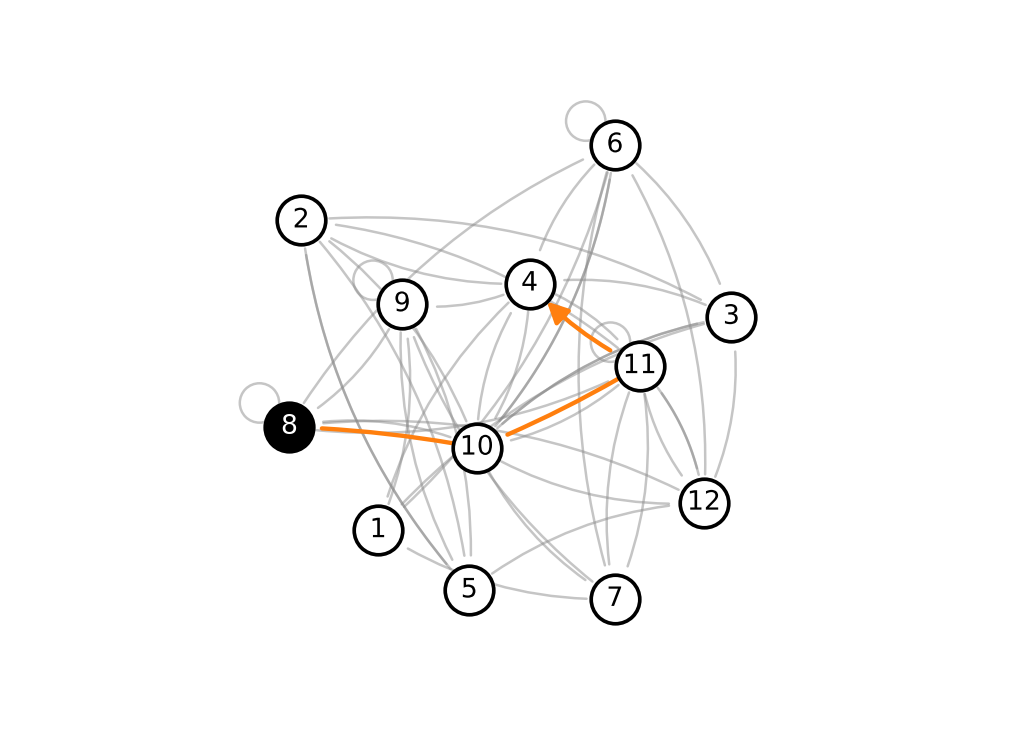

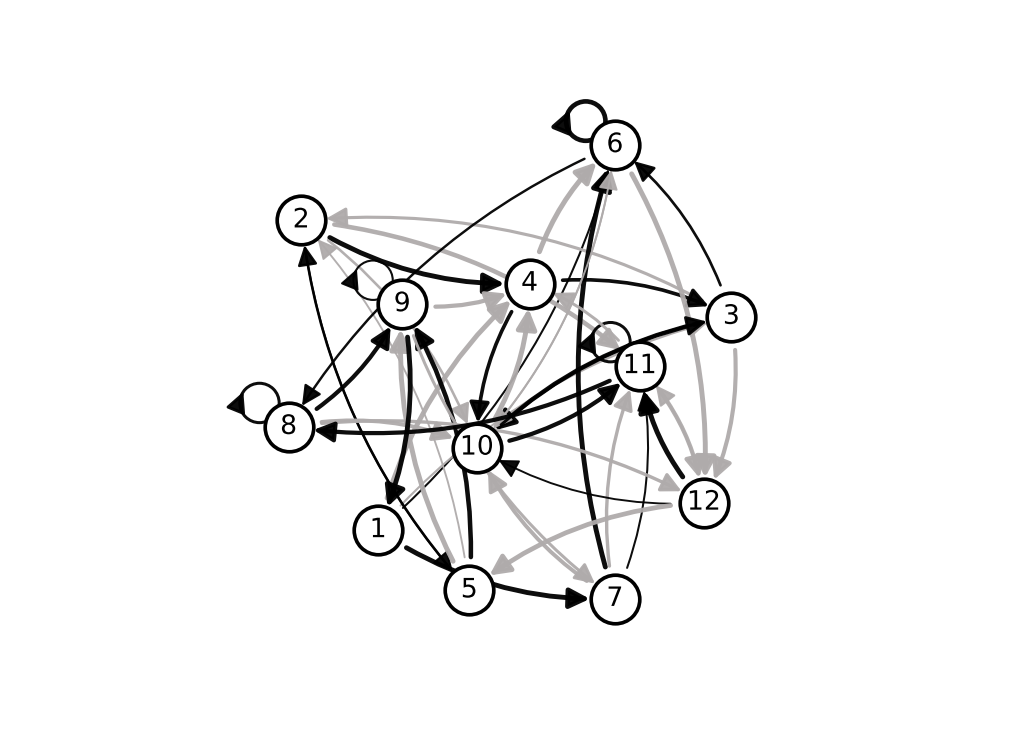

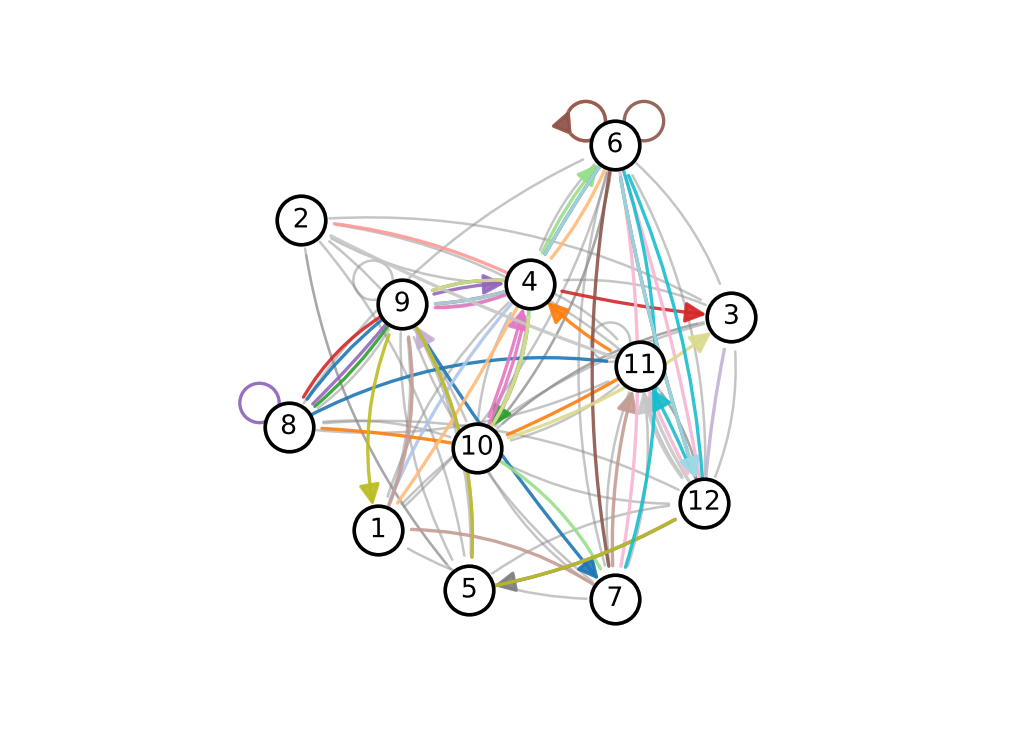

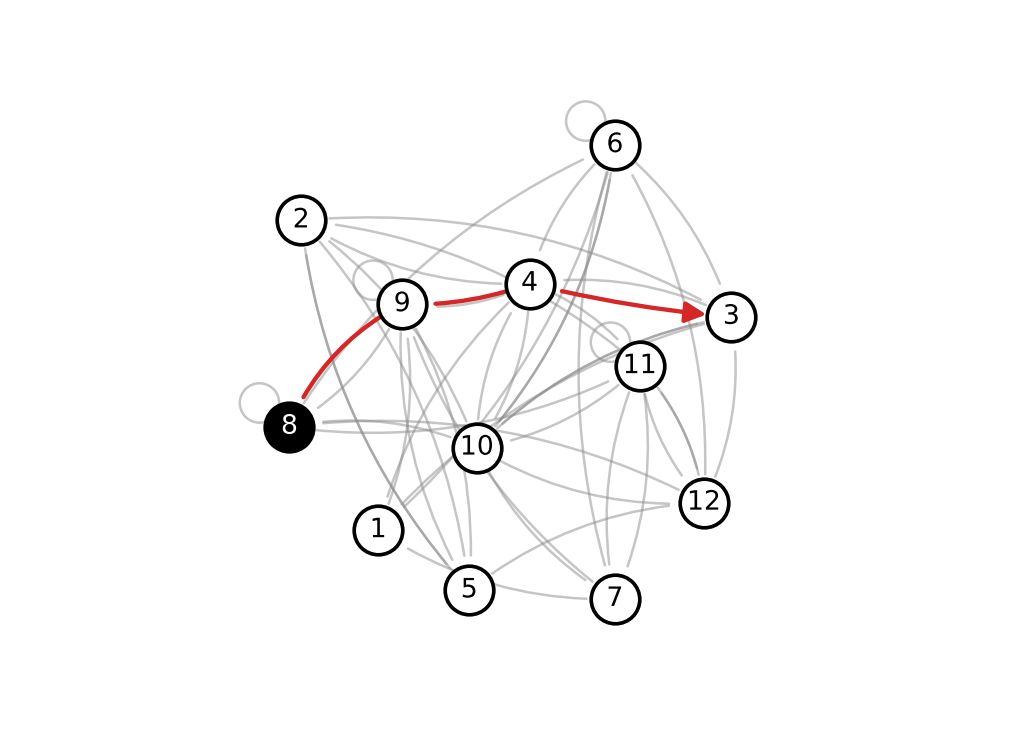

In [12]:
# ──────────────────────────────────────────────────────────────────────────────
# Build the MDP and the four synchronized 2D figures
# ──────────────────────────────────────────────────────────────────────────────

rng = np.random.default_rng(BASE_SEED)

P = build_random_mdp(
    rng,
    N=N,
    A=A,
    K=K,
)

P = force_demo_transitions(P)

action1_fast_probability = float(
    P[0, 7, 8] * P[1, 8, 3]
)

max_action2_probability = (
    MAX_ACTION2_RELATIVE_TO_ACTION1
    * action1_fast_probability
)

action2_result = find_three_step_path_after_action2(
    P,
    start=7,
    target=3,
    first_action=1,
    require_distinct_states=True,
    min_path_probability=MIN_ACTION2_PATH_PROBABILITY,
    max_path_probability=max_action2_probability,
)

if action2_result is None:
    raise RuntimeError(
        "No valid three-step action-2 path was found "
        f"for seed {BASE_SEED}."
    )

action2_states, action2_actions, action2_probability = action2_result

episodes, action_lists = generate_episodes_with_actions(
    P,
    num_episodes=NUM_EPISODES,
    ep_len=EPISODE_LEN,
    rng=rng,
)

episodes, action_lists = insert_demo_episodes(
    P,
    episodes,
    action_lists,
    rng,
    action2_states=action2_states,
    action2_actions=action2_actions,
)

G = edges_from_mdp(
    P,
    prob_threshold=PROB_THRESHOLD,
)

# Shared positions used by all four figures.
pos = {
    k: tuple(v)
    for k, v in reference_style_positions().items()
}

limits = fixed_limits_from_positions(pos)

cmap = matplotlib.colormaps.get_cmap("tab20")
episode_colors = cmap(
    np.linspace(
        0,
        1,
        len(episodes),
    )
)

path1 = list(
    episodes[PATH1_EPISODE_INDEX][:4]
)

path2 = list(
    episodes[PATH2_EPISODE_INDEX][:4]
)

print("Seed:", BASE_SEED)

print(
    "Path 1:",
    " -> ".join(str(s + 1) for s in path1),
)

print(
    "Path 2:",
    " -> ".join(str(s + 1) for s in path2),
)

print(
    "Path 2 actions:",
    [a + 1 for a in action2_actions],
)

print(
    f"Path 2 probability: {action2_probability:.6f}"
)

print(
    f"Action-1 two-step probability: "
    f"{action1_fast_probability:.6f}"
)


# Figure 1: raw MDP
fig1, ax1 = plt.subplots(
    figsize=FIGSIZE,
    dpi=DPI,
)

# Figure 2: MDP with all episodes
fig2, ax2 = plt.subplots(
    figsize=FIGSIZE,
    dpi=DPI,
)

# Figure 3: path 1
fig3, ax3 = plt.subplots(
    figsize=FIGSIZE,
    dpi=DPI,
)

# Figure 4: path 2
fig4, ax4 = plt.subplots(
    figsize=FIGSIZE,
    dpi=DPI,
)


draw_functions = [
    lambda: draw_raw_mdp(
        ax1,
        G,
        pos,
        limits,
    ),

    lambda: draw_all_episodes_2d(
        ax2,
        G,
        pos,
        episodes,
        episode_colors,
        limits,
    ),

    lambda: draw_single_episode_2d(
        ax3,
        G,
        pos,
        path1,
        episode_colors[PATH1_EPISODE_INDEX],
        limits,
        "Path 1",
        PATH1_EPISODE_INDEX,
    ),

    lambda: draw_single_episode_2d(
        ax4,
        G,
        pos,
        path2,
        episode_colors[PATH2_EPISODE_INDEX],
        limits,
        "Path 2",
        PATH2_EPISODE_INDEX,
    ),
]


editor = SyncedDraggableFourFigures(
    pos=pos,
    fig_axes=[
        (fig1, ax1),
        (fig2, ax2),
        (fig3, ax3),
        (fig4, ax4),
    ],
    draw_functions=draw_functions,
)

fig1.tight_layout()
fig2.tight_layout()
fig3.tight_layout()
fig4.tight_layout()

print()
print(
    "Drag a node in any of the four figures. "
    "The same node moves in all four figures."
)
print(
    "Each episode in Figures 2, 3 and 4 has only one arrowhead, "
    "at the end of the episode."
)

plt.show()


Seed: 1
Path 1: 8 -> 9 -> 4 -> 3
Path 2: 8 -> 10 -> 11 -> 4
Path 2 actions: [2, 1, 2]
Path 2 probability: 0.117746
Action-1 two-step probability: 0.490000

Drag a node in any of the four figures. The same node moves in all four figures.
Each episode in Figures 2, 3 and 4 has only one arrowhead, at the end of the episode.


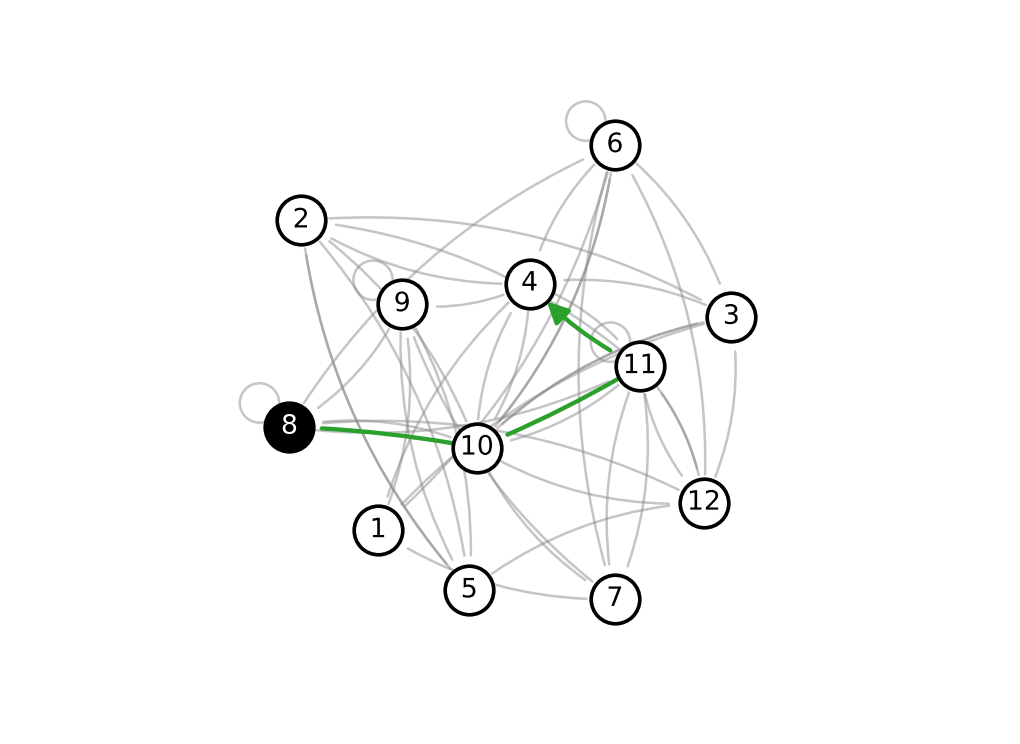

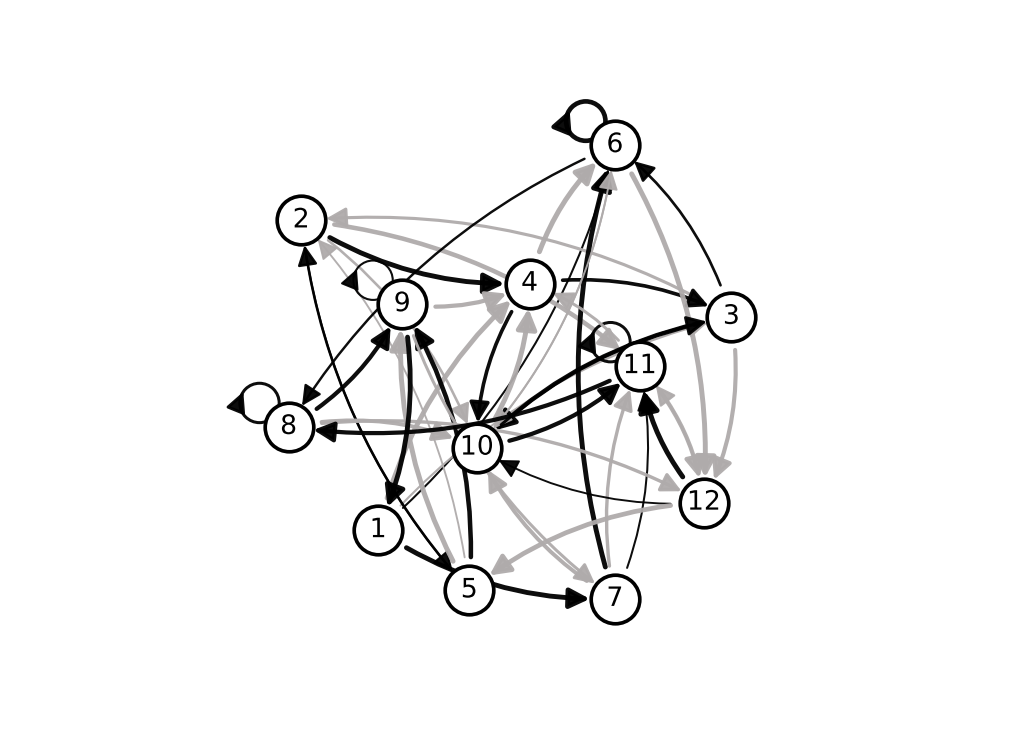

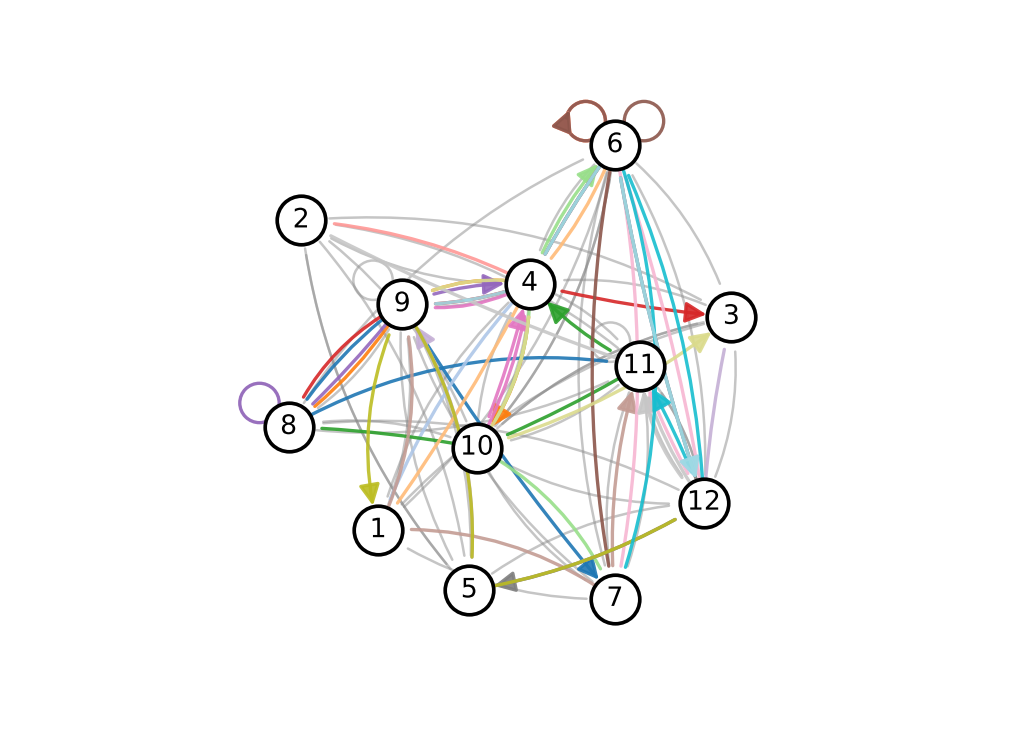

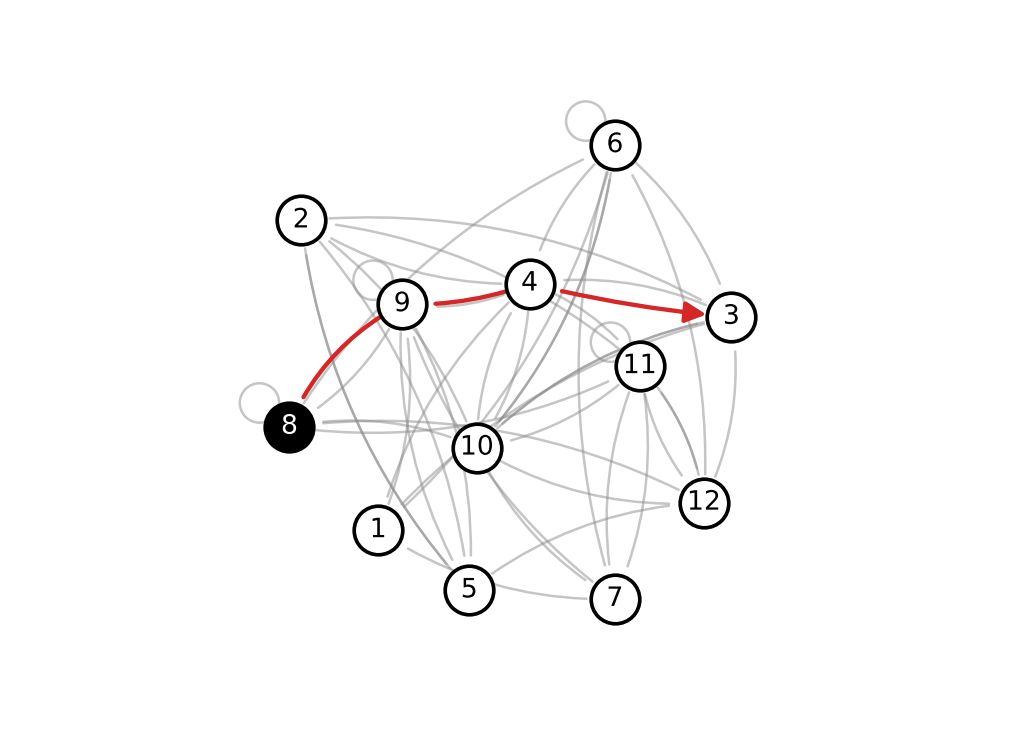

In [14]:
# ──────────────────────────────────────────────────────────────────────────────
# Build the MDP and the four synchronized 2D figures
# ──────────────────────────────────────────────────────────────────────────────

rng = np.random.default_rng(BASE_SEED)

P = build_random_mdp(
    rng,
    N=N,
    A=A,
    K=K,
)

P = force_demo_transitions(P)

action1_fast_probability = float(
    P[0, 7, 8] * P[1, 8, 3]
)

max_action2_probability = (
    MAX_ACTION2_RELATIVE_TO_ACTION1
    * action1_fast_probability
)

action2_result = find_three_step_path_after_action2(
    P,
    start=7,
    target=3,
    first_action=1,
    require_distinct_states=True,
    min_path_probability=MIN_ACTION2_PATH_PROBABILITY,
    max_path_probability=max_action2_probability,
)

if action2_result is None:
    raise RuntimeError(
        "No valid three-step action-2 path was found "
        f"for seed {BASE_SEED}."
    )

action2_states, action2_actions, action2_probability = action2_result

episodes, action_lists = generate_episodes_with_actions(
    P,
    num_episodes=NUM_EPISODES,
    ep_len=EPISODE_LEN,
    rng=rng,
)

episodes, action_lists = insert_demo_episodes(
    P,
    episodes,
    action_lists,
    rng,
    action2_states=action2_states,
    action2_actions=action2_actions,
)

G = edges_from_mdp(
    P,
    prob_threshold=PROB_THRESHOLD,
)

# Shared positions used by all four figures.
pos = {
    k: tuple(v)
    for k, v in reference_style_positions().items()
}

limits = fixed_limits_from_positions(pos)

cmap = matplotlib.colormaps.get_cmap("tab20")

episode_colors = cmap(
    np.linspace(
        0,
        1,
        len(episodes),
    )
)

# Swap Path 2's original color with the episode that is currently tab:green.
target_green = np.array(
    matplotlib.colors.to_rgba("tab:green")
)

path2_original_color = episode_colors[
    PATH2_EPISODE_INDEX
].copy()

green_indices = [
    i
    for i, color in enumerate(episode_colors)
    if i != PATH2_EPISODE_INDEX
    and np.allclose(color, target_green)
]

if green_indices:
    green_index = green_indices[0]

    episode_colors[green_index] = path2_original_color

episode_colors[PATH2_EPISODE_INDEX] = target_green

path1 = list(
    episodes[PATH1_EPISODE_INDEX][:4]
)

path2 = list(
    episodes[PATH2_EPISODE_INDEX][:4]
)

print("Seed:", BASE_SEED)

print(
    "Path 1:",
    " -> ".join(str(s + 1) for s in path1),
)

print(
    "Path 2:",
    " -> ".join(str(s + 1) for s in path2),
)

print(
    "Path 2 actions:",
    [a + 1 for a in action2_actions],
)

print(
    f"Path 2 probability: {action2_probability:.6f}"
)

print(
    f"Action-1 two-step probability: "
    f"{action1_fast_probability:.6f}"
)


# Figure 1: raw MDP
fig1, ax1 = plt.subplots(
    figsize=FIGSIZE,
    dpi=DPI,
)

# Figure 2: MDP with all episodes
fig2, ax2 = plt.subplots(
    figsize=FIGSIZE,
    dpi=DPI,
)

# Figure 3: path 1
fig3, ax3 = plt.subplots(
    figsize=FIGSIZE,
    dpi=DPI,
)

# Figure 4: path 2
fig4, ax4 = plt.subplots(
    figsize=FIGSIZE,
    dpi=DPI,
)


draw_functions = [
    lambda: draw_raw_mdp(
        ax1,
        G,
        pos,
        limits,
    ),

    lambda: draw_all_episodes_2d(
        ax2,
        G,
        pos,
        episodes,
        episode_colors,
        limits,
    ),

    lambda: draw_single_episode_2d(
        ax3,
        G,
        pos,
        path1,
        episode_colors[PATH1_EPISODE_INDEX],
        limits,
        "Path 1",
        PATH1_EPISODE_INDEX,
    ),

    lambda: draw_single_episode_2d(
        ax4,
        G,
        pos,
        path2,
        episode_colors[PATH2_EPISODE_INDEX],
        limits,
        "Path 2",
        PATH2_EPISODE_INDEX,
    ),
]


editor = SyncedDraggableFourFigures(
    pos=pos,
    fig_axes=[
        (fig1, ax1),
        (fig2, ax2),
        (fig3, ax3),
        (fig4, ax4),
    ],
    draw_functions=draw_functions,
)

fig1.tight_layout()
fig2.tight_layout()
fig3.tight_layout()
fig4.tight_layout()

print()
print(
    "Drag a node in any of the four figures. "
    "The same node moves in all four figures."
)

print(
    "Each episode in Figures 2, 3 and 4 has only one arrowhead, "
    "at the end of the episode."
)

plt.show()

In [18]:
# Optional: print the current positions again at any time.

print("FIXED_POS = {")
for i in range(N):
    x, y = pos[i]
    print(
        f"    {i}: ({x:.6f}, {y:.6f}),"
    )
print("}")


FIXED_POS = {
    0: (-1.615215, -1.847230),
    1: (-2.512769, 1.769782),
    2: (2.510859, 0.644490),
    3: (0.153103, 1.032984),
    4: (-0.550000, -2.550000),
    5: (1.150000, 2.650000),
    6: (1.150000, -2.650000),
    7: (-2.660129, -0.641559),
    8: (-1.333891, 0.791849),
    9: (-0.463129, -0.882693),
    10: (1.439151, 0.068447),
    11: (2.189346, -1.525718),
}


In [19]:
def draw_transition_matrix(P):
    """Plot the two actions as adjacent node by node transition matrices."""
    A, N, N_to = P.shape

    if N != N_to:
        raise ValueError("P must have shape (actions, nodes, nodes)")
    if A != 2:
        raise ValueError("This layout expects exactly two actions")

    fig, axes = plt.subplots(
        1, 2,
        figsize=(max(7.0, 0.75 * N)*0.6, max(3.0, 0.32 * N)*0.6),
        dpi=300,
        sharex=True,
        sharey=True,
        constrained_layout=True
    )

    images = []

    for a, ax in enumerate(axes):
        image = ax.imshow(
            P[a],
            cmap="Blues",
            vmin=0,
            vmax=1,
            interpolation="none",
            aspect="equal"
        )
        images.append(image)

        ax.set_title(f"Action {a + 1}")
        ax.set_xlabel("Resulting node")

        ax.set_xticks(np.arange(1, N + 1,2))
        ax.set_xticklabels(np.arange(2, N + 1,2))
        ax.set_yticks(np.arange(1, N + 1,2))
        ax.set_yticklabels(np.arange(2, N + 1,2))
        ax.tick_params(axis="y", labelleft=True)
        ax.set_xticks(np.arange(-0.5, N, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, N, 1), minor=True)
        ax.grid(
            which="minor",
            color=(0.80, 0.80, 0.80),
            linewidth=0.45
        )
        ax.tick_params(which="minor", bottom=False, left=False)

#         for source in range(N):
#             for destination in range(N):
#                 p = float(P[a, source, destination])
#                 if p > 1e-12:
#                     ax.text(
#                         destination,
#                         source,
#                         f"{p:.2f}",
#                         ha="center",
#                         va="center",
#                         fontsize=6.5,
#                         color="white" if p >= 0.55 else "#08306b"
#                     )

    axes[0].set_ylabel("Source node")

    fig.colorbar(
        images[0],
        ax=axes,
        label="Transition probability",
        fraction=0.035,
        pad=0.03
    )

    P_matrix = P.transpose(1, 0, 2).reshape(N * A, N)
    return fig, axes, P_matrix

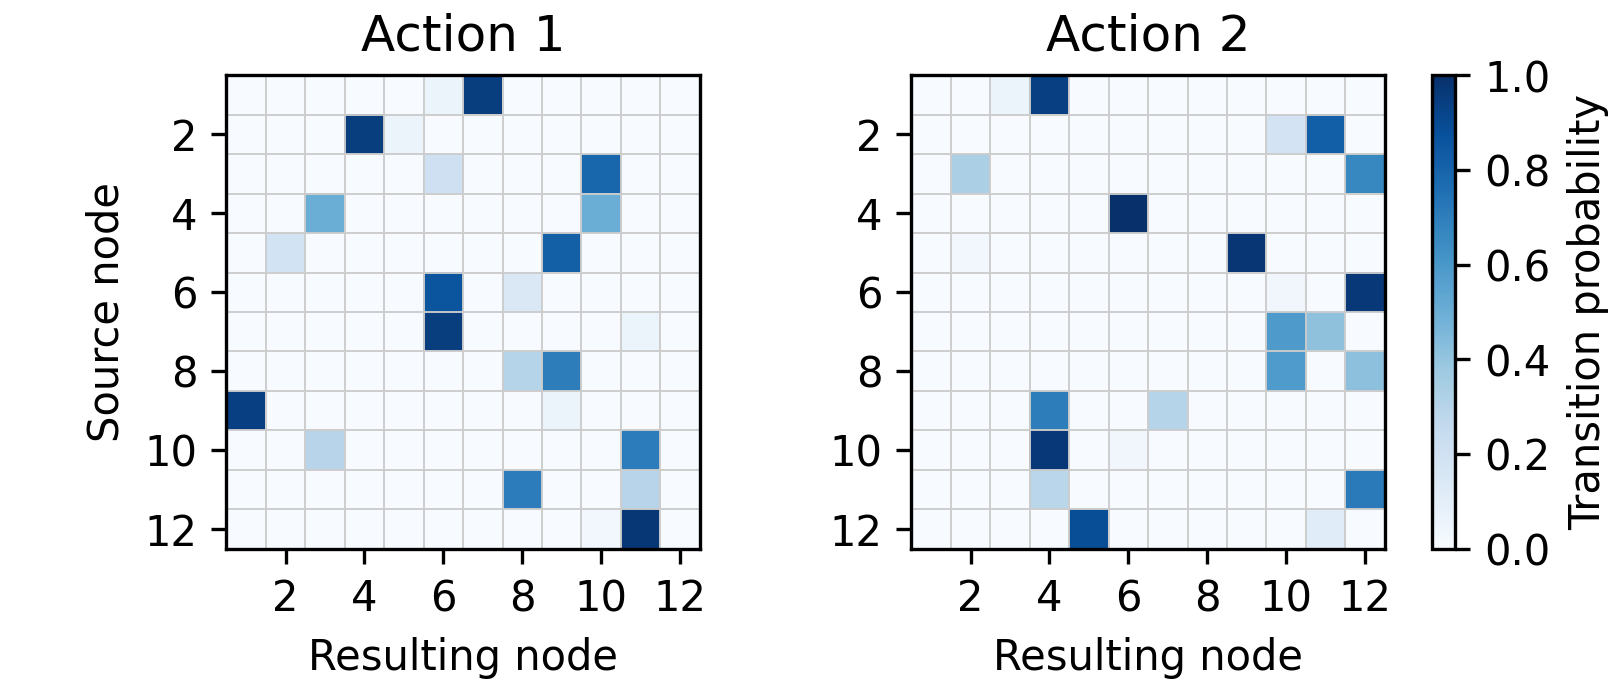

In [20]:
draw_transition_matrix(P)
plt.show()